C:\Users\pmlbl\AppData\Local\Temp\ipykernel_39436\2137772588.py:87: UserWarning: Warning: converting a masked element to nan.
  if math.isnan(data[i,j]):


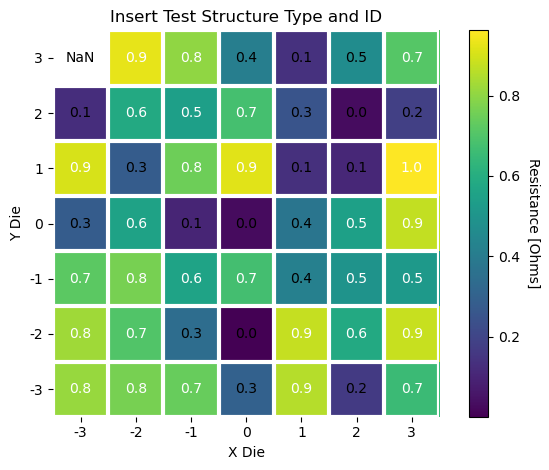

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import math

def heatmap(data, grid, ax, cbarlabel, **kwargs):
    """
    Creates a heatmap from a numpy array and two lists of labels.

    Args:
        :data: 2D numpy array of shape (M, N).
        :grid: Size of plot grid in gridxgrid dimensions
        :ax: 'matplotlib.axes.Axes` instance to which the heatmap is plotted.
        :cbarlabel: The label for the colorbar.  Optional.
        :**kwargs:All other arguments are forwarded to `imshow`.
    Returns:
        :im: AxesImage to be labeled
        :cbar:
    """
    #defines x and y size of plot grid
    mid = grid/2
    x = range(-(math.floor(mid)),math.ceil(mid))
    y = range((math.floor(mid)),-(math.ceil(mid)),-1)

    # Plot the heatmap   
    im = ax.imshow(data, **kwargs)

    # Create colorbar
    cbar = ax.figure.colorbar(im, ax=ax)
    cbar.ax.set_ylabel(cbarlabel, rotation=-90, va="bottom")

    # Show all ticks and label them with the respective list entries.
    ax.set_xticks(range(data.shape[1]), labels=x)
    ax.set_xlabel('X Die')
    ax.set_yticks(range(data.shape[0]), labels=y)
    ax.set_ylabel('Y Die')
    ax.set_title("Insert Test Structure Type and ID")

    # Turn spines off and create white grid.
    ax.spines[:].set_visible(False)
    ax.set_xticks(np.arange(data.shape[1]+1)-.5, minor=True)
    ax.set_yticks(np.arange(data.shape[0]+1)-.5, minor=True)
    ax.grid(which="minor", color="w", linestyle='-', linewidth=3)
    ax.tick_params(which="minor", bottom=False, left=False)

    return im, cbar


def annotate_heatmap(im, data=None, valfmt="{x:.2f}", textcolors=("black", "white"), threshold=None, **textkw):
    """
    A function to annotate a heatmap.

    Args
        :im: The AxesImage to be labeled.
        :data: Data used to annotate.  If None, the image's data is used.  Optional.
        :valfmt: The format of the annotations inside the heatmap.  This should either use the string format method, e.g. "$ {x:.2f}", or be a`matplotlib.ticker.Formatter`.  Optional.
        :textcolors: A pair of colors.  The first is used for values below a threshold, the second for those above.  Optional.
        :threshold: Value in data units according to which the colors from textcolors are applied.  If None (the default) uses the middle of the colormap as separation.  Optional.
        :**kwargs: All other arguments are forwarded to each call to `text` used to createthe text labels.
    Returns

    """

    if not isinstance(data, (list, np.ndarray)):
        data = im.get_array()

    # Normalize the threshold to the images color range.
    if threshold is not None:
        threshold = im.norm(threshold)
    else:
        threshold = im.norm(data.max())/2.

    # Set default alignment to center, but allow it to be
    # overwritten by textkw.
    kw = dict(horizontalalignment="center", verticalalignment="center")
    kw.update(textkw)

    # Get the formatter in case a string is supplied
    if isinstance(valfmt, str):
        valfmt = mpl.ticker.StrMethodFormatter(valfmt)

    # Loop over the data and create a `Text` for each "pixel".
    # Change the text's color depending on the data.
    texts = []
    for i in range(data.shape[0]):
        for j in range(data.shape[1]):
            if math.isnan(data[i,j]):
                text = im.axes.text(j, i, 'NaN', **kw)
            else:
                kw.update(color=textcolors[int(im.norm(data[i, j]) > threshold)])
                text = im.axes.text(j, i, valfmt(data[i, j], None), **kw)
            texts.append(text)
    return texts
    
z = np.random.rand(7,7)

z[0,0] = math.nan
# plot heatmap
fig, ax = plt.subplots()
cmap = mpl.colormaps.get_cmap('viridis')
cmap.set_bad(color='white')

im, cbar = heatmap(z, 7, ax=ax, cbarlabel="Resistance [Ohms]",cmap=cmap)
texts = annotate_heatmap(im, valfmt="{x:.2f}")
fig.tight_layout()
plt.show()